## Exploración de la producción solar de Cuernavaca

Este notebook genera las figuras presentadas en el curso el dia 2:

1. la serie completa y una semana representativa;
2. el ciclo diario, el cambio estacional y la variabilidad;
3. la relación entre la producción actual y sus rezagos de 1, 24 y 168 horas.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


df = pd.read_csv('data/solar_8760h.csv')
df["time"] = pd.date_range("2019-01-01", periods=len(df), freq="h")
df = df.set_index("time")
df["month"] = df.index.month
df["hour_of_day"] = df.index.hour



print("Observaciones:", len(df))
print("Periodo:", df.index.min(), "a", df.index.max())
print("Energía anual:", round(df.pv_kw_per_kwp.sum(), 1), "kWh/kWp")
print("Fracción de horas nocturnas:", round((df.pv_kw_per_kwp == 0).mean(), 3))
display(df[["pv_kw_per_kwp", "ghi_kw_m2", "temp_c"]].describe().round(3))

# Configuración común de fuentes para gráficas
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


Observaciones: 8760
Periodo: 2019-01-01 00:00:00 a 2019-12-31 23:00:00
Energía anual: 1840.5 kWh/kWp
Fracción de horas nocturnas: 0.505


,pv_kw_per_kwp,ghi_kw_m2,temp_c
count,8760.000,8760.000,8760.000
mean,0.210,0.267,18.726
std,0.275,0.354,5.424
min,0.000,0.000,5.342
25%,0.000,0.000,14.743
50%,0.000,0.012,17.630
75%,0.437,0.528,22.773
max,0.836,1.164,34.053


## 1. Serie anual y semana representativa

La gráfica superior sitúa la producción dentro del año. La inferior permite ver el ciclo día-noche y el cambio de un día al siguiente con suficiente detalle para comentarlo en clase.

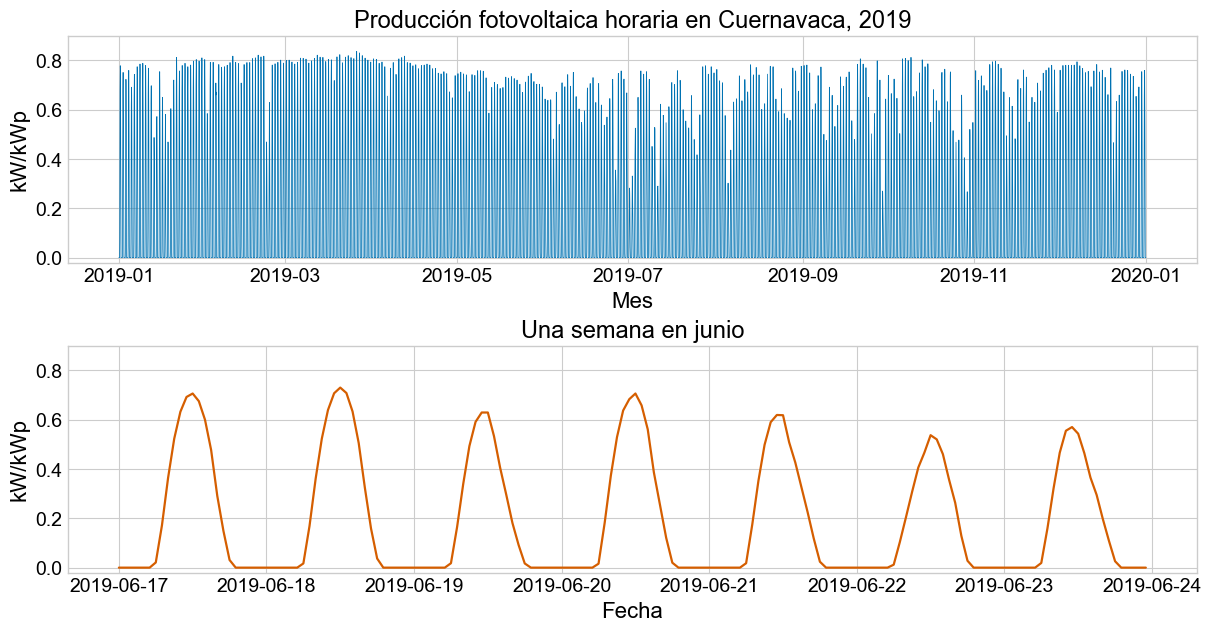

In [27]:
# Gráficamos una semana de datos
week_start = pd.Timestamp("2019-06-17 00:00")
week_end = week_start + pd.Timedelta(days=7)
week = df.loc[week_start:week_end - pd.Timedelta(hours=1)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), constrained_layout=True)
axes[0].plot(df.index, df.pv_kw_per_kwp, color="#0072B2", lw=0.55)
axes[0].set(title="Producción fotovoltaica horaria en Cuernavaca, 2019", ylabel="kW/kWp", xlabel="Mes", ylim=(-0.02, 0.9))

axes[1].plot(week.index, week.pv_kw_per_kwp, color="#D55E00", lw=1.6)
axes[1].set(title="Una semana en junio", ylabel="kW/kWp",  xlabel="Fecha", ylim=(-0.02, 0.9),)
fig.savefig('Figures/solar_series.pdf', dpi=220, bbox_inches="tight")
plt.show()

## 2. Ciclo diario, estacionalidad y variabilidad

El perfil promedio por hora muestra el ciclo diario. Comparar enero, junio y diciembre ilustra que ese perfil cambia con la época del año. La energía diaria evidencia que incluso días cercanos pueden diferir por las condiciones atmosféricas.

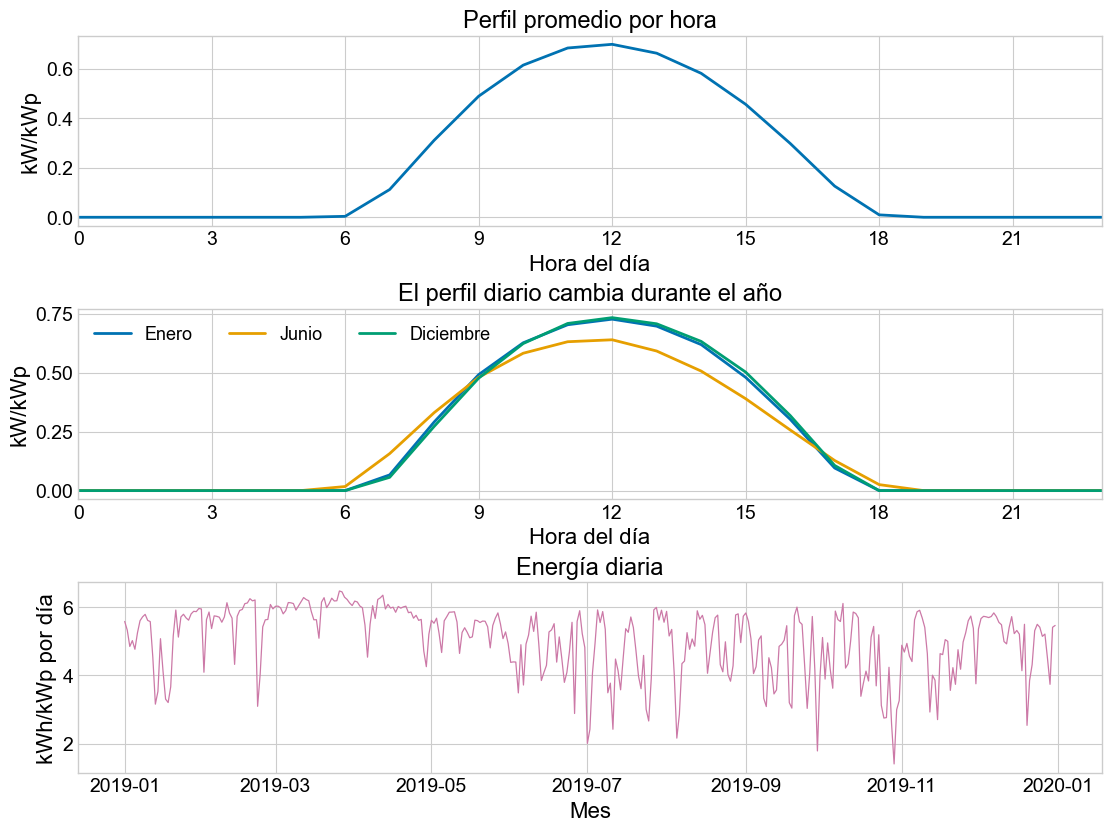

In [32]:
hourly_profile = df.groupby("hour_of_day").pv_kw_per_kwp.mean()
profiles = df[df.month.isin([1, 6, 12])].groupby(["month", "hour_of_day"]).pv_kw_per_kwp.mean()
daily_energy = df.pv_kw_per_kwp.resample("D").sum()

fig, axes = plt.subplots(3, 1, figsize=(11, 8.2), constrained_layout=True)

axes[0].plot(hourly_profile.index, hourly_profile, color="#0072B2", lw=2)
axes[0].set(title="Perfil promedio por hora", xlabel="Hora del día", ylabel="kW/kWp", xlim=(0, 23), xticks=np.arange(0, 24, 3))

colors = {1: "#0072B2", 6: "#E69F00", 12: "#009E73"}
labels = {1: "Enero", 6: "Junio", 12: "Diciembre"}
for month in (1, 6, 12):
    axes[1].plot( np.arange(24), profiles.loc[month], color=colors[month], lw=2, label=labels[month])
axes[1].set(
    title="El perfil diario cambia durante el año",
    xlabel="Hora del día",
    ylabel="kW/kWp",
    xlim=(0, 23),
    xticks=np.arange(0, 24, 3),
)
axes[1].legend(ncol=3)

axes[2].plot(daily_energy.index, daily_energy, color="#CC79A7", lw=0.9)
axes[2].set(
    title="Energía diaria",
    xlabel="Mes",
    ylabel="kWh/kWp por día",
)
#save_figure(fig, "solar_structure")
fig.savefig('Figures/solar_structure.pdf', dpi=220, bbox_inches="tight")
plt.show()

## 3. ¿La serie tiene memoria?

Cada panel compara la generación de una hora con una observación anterior. La correlación resume una asociación lineal, mientras que la nube de puntos permite ver los ceros nocturnos y la variabilidad alrededor del patrón diario.

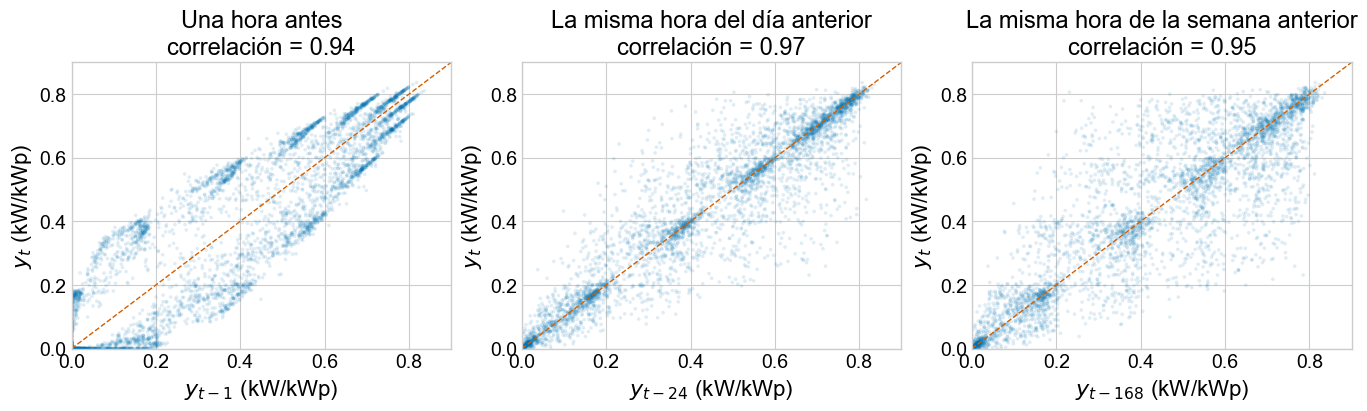

In [30]:
lags = [1, 24, 168]
labels = {
    1: "Una hora antes",
    24: "La misma hora del día anterior",
    168: "La misma hora de la semana anterior",
}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), constrained_layout=True)
for ax, lag in zip(axes, lags):
    pair = pd.DataFrame({"lag": df.pv_kw_per_kwp.shift(lag), "actual": df.pv_kw_per_kwp}).dropna()
    correlation = pair.lag.corr(pair.actual)
    ax.scatter(pair.lag, pair.actual, s=7, alpha=0.12, color="#0072B2", edgecolors="none")
    ax.plot([0, 0.9], [0, 0.9], color="#D55E00", lw=1, ls="--")
    ax.set(
        title=f"{labels[lag]}\ncorrelación = {correlation:.2f}",
        xlabel=fr"$y_{{t-{lag}}}$ (kW/kWp)",
        ylabel=r"$y_t$ (kW/kWp)",
        xlim=(0, 0.9),
        ylim=(0, 0.9),
    )
fig.savefig('Figures/solar_lags.pdf', dpi=220, bbox_inches="tight")

plt.show()

### 4. La correlación de una hora depende de la hora del día

Una sola correlación global mezcla la noche, el amanecer, el mediodía y el atardecer. Aquí calculamos la correlación entre \(y_t\) y \(y_{t-1}\) por separado para cada hora del día. El panel superior muestra el patrón solar promedio que ayuda a interpretar el resultado.

/var/folders/kn/x4q763px20v716s523gz79hm0000gn/T/ipykernel_45263/3443934667.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_correlation = lag1.groupby("hour").apply(


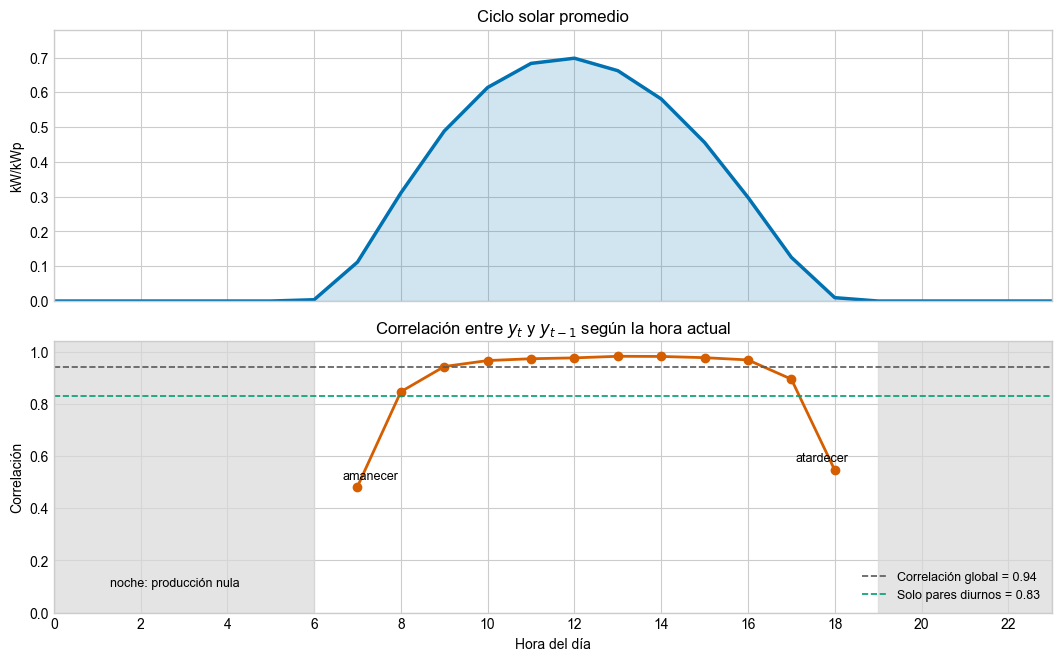

,correlacion_y_t_y_t_1
hour,
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,0.48
8,0.85


In [20]:
lag1 = pd.DataFrame({
    "pv": df.pv_kw_per_kwp,
    "lag1": df.pv_kw_per_kwp.shift(1),
    "hour": df.index.hour,
}).dropna()
hourly_correlation = lag1.groupby("hour").apply(
    lambda group: group[["pv", "lag1"]].corr().iloc[0, 1]
)
daytime = lag1[(lag1.pv > 0) & (lag1.lag1 > 0)]

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(hourly_profile.index, hourly_profile, color="#0072B2", lw=2.5)
axes[0].fill_between(hourly_profile.index, 0, hourly_profile, color="#0072B2", alpha=0.18)
axes[0].set(title="Ciclo solar promedio", ylabel="kW/kWp", ylim=(0, 0.78))

hours = np.arange(24)
valid = hourly_correlation.notna()
axes[1].plot(hours[valid], hourly_correlation[valid], marker="o", color="#D55E00", lw=2)
axes[1].axhline(lag1[["pv", "lag1"]].corr().iloc[0, 1], color="0.35", ls="--", lw=1.2, label="Correlación global = 0.94")
axes[1].axhline(daytime[["pv", "lag1"]].corr().iloc[0, 1], color="#009E73", ls="--", lw=1.2, label="Solo pares diurnos = 0.83")
axes[1].axvspan(0, 6, color="0.85", alpha=0.7)
axes[1].axvspan(19, 23, color="0.85", alpha=0.7)
axes[1].annotate("noche: producción nula", xy=(2.8, 0.1), ha="center", fontsize=9)
axes[1].annotate("amanecer", xy=(7.3, 0.51), ha="center", fontsize=9)
axes[1].annotate("atardecer", xy=(17.7, 0.58), ha="center", fontsize=9)
axes[1].set(
    title=r"Correlación entre $y_t$ y $y_{t-1}$ según la hora actual",
    xlabel="Hora del día",
    ylabel="Correlación",
    xlim=(0, 23),
    xticks=np.arange(0, 24, 2),
    ylim=(0, 1.04),
)
axes[1].legend(loc="lower right", fontsize=9)
fig.savefig('Figures/solar_lag1_by_hour.pdf', dpi=220, bbox_inches="tight")

plt.show()


display(hourly_correlation.rename("correlacion_y_t_y_t_1").to_frame().round(2))